In [1]:
"""Calculate pseudobulk and PCA for each cell type in Xenium data."""

import logging
import os
import random
import re
from datetime import datetime
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import sklearn
import torch
from adjustText import adjust_text
from matplotlib import transforms
from matplotlib.patches import Ellipse
from scipy.sparse import issparse


In [2]:
# Functions
def seed_everything(seed: int):
    """Set random seed on every random module for reproducibility.

    Args:
        seed: The seed value to set for random number generation.
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True
    elif torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    else:
        pass

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor="none", **kwargs):
    """Draw a covariance confidence ellipse for points (x, y) on ax.

    Args:
        x: Array of x coordinates of the points.
        y: Array of y coordinates of the points.
        ax: Matplotlib Axes to draw on.
        n_std: Number of standard deviations for ellipse radius (default 2 = ~95%).
        facecolor: Fill color of ellipse (default 'none' = transparent).
        **kwargs: Passed to matplotlib Ellipse patch (edgecolor, linewidth, linestyle, etc.)

    Returns:
        None
    """
    if len(x) < 2:
        return  # can't compute covariance with a single point

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])

    # Eigenvalue-based radii
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        facecolor=facecolor,
        **kwargs,
    )

    # Scale to n_std standard deviations and translate to mean
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)

    transform = (
        transforms.Affine2D()
        .rotate_deg(45)
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)
    )
    ellipse.set_transform(transform + ax.transData)
    ax.add_patch(ellipse)

def safe_name(x):
    """Convert a string to a safe format for filenames and identifiers."""
    x = str(x)
    x = x.strip().replace(" ", "_")
    x = re.sub(r"\s+", "_", x)
    x = re.sub(r"[^A-Za-z0-9_.-]", "_", x)
    x = re.sub(r"_+", "_", x)
    return x


In [3]:
# Set random seed for reproducibility
seed_everything(19960915)

In [4]:
# Set color palette for conditions
palette = sns.color_palette("Set2")
col_palettes = {"IPF": "#fc8d62", "COPD": "#66c2a5", "MICA": "#8da0cb", "PM08": "#e78ac3"}

In [5]:
# Set directory for saving results
dir = Path("/Volumes/sep22/projects/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/2026-03-27_analysis_run/project_analysis/general/")

output_dir = dir / "pb_pca/_manual"
output_dir.mkdir(parents=True, exist_ok=True)

In [6]:
# Load data
pb_sample = pd.read_csv(
    dir /"pb_data/pseudobulk_matrix_ROI.csv",
    index_col=0,
)
meta = pd.read_csv(dir /"pb_data/pseudobulk_metadata_ROI.csv", index_col=0)

In [17]:
meta

,n_cells,total_counts,mean_transcripts,sample_ID,batch,condition,timepoint,timepoint_label,sample_ID_manual,time_point,...,ppFEV1,ppFVC,FEV1_FVC,ppRV,ppTLC,RV_TLC,TLCO,ppTLCO,KCO,KCO_percent
ROI,,,,,,,,,,,,,,,,,,,,,
COPD_46005_V1,23129,1739235.0,75.197155,COPD_46005,4,COPD,V1,baseline,COPD_46005,V1,...,0.360,1.000,0.2800,1.98,1.41,0.5723,NaN,NaN,NaN,NaN
COPD_46005_V2,25141,1894234.0,75.344417,COPD_46005,4,COPD,V2,6_weeks,COPD_46005,V2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COPD_R003_V1,17710,860335.0,48.579051,COPD_R003,2,COPD,V1,baseline,COPD_R003,V1,...,0.300,0.700,0.2852,1.55,0.99,0.5466,NaN,NaN,NaN,NaN
COPD_R003_V2,33066,5211067.0,157.595929,COPD_R003,3,COPD,V2,6_weeks,COPD_R003,V2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COPD_R003_V3,4841,388271.0,80.204710,COPD_R003,1,COPD,V3,6_months,COPD_R003,V3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COPD_R009_V1,12921,1404592.0,108.706137,COPD_R009,2,COPD,V1,baseline,COPD_R009,V1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COPD_R009_V2,38399,4851330.0,126.340009,COPD_R009,2,COPD,V2,6_weeks,COPD_R009,V2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COPD_R009_V3,36978,5699096.0,154.121261,COPD_R009,1,COPD,V3,6_months,COPD_R009,V3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COPD_R010_V2,25500,3743171.0,146.791020,COPD_R010,1,COPD,V2,6_weeks,COPD_R010,V1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/3762670905.py:6: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxenplot(data=meta, y=y, hue="condition", palette=palette, legend=True, saturation=0.25)
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/3762670905.py:7: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.stripplot(data=meta, y=y, hue="condition", palette=palette, dodge=True, jitter=True, ax=plt.gca(), legend=False)
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/3762670905.py:6: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxenplot(data=meta, y=y, hue="condition", palette=palette, legend=True, saturation=0.25)
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/3762670905.py:7: UserWarning: The palette list has more values (8) than needed (4), which may no

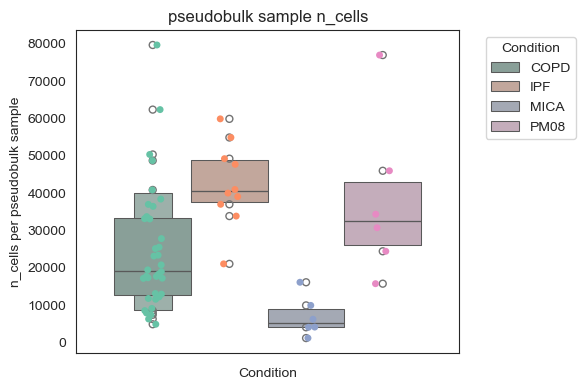

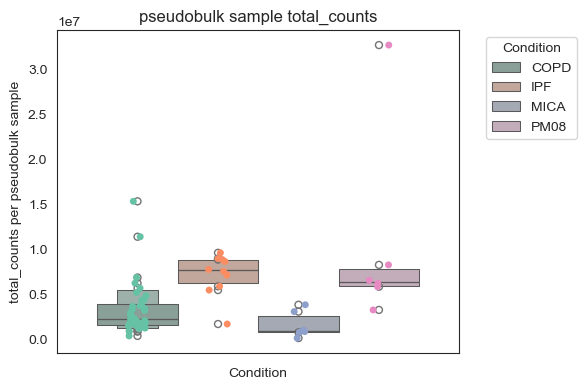

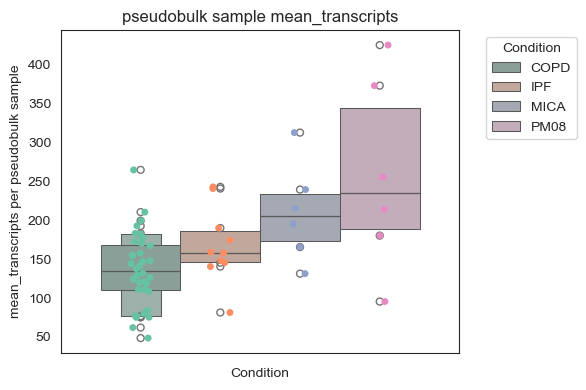

In [21]:
y_list = ["n_cells", "total_counts", "mean_transcripts"]

for y in y_list:
    safe_y = safe_name(y)
    plt.figure(figsize=(6, 4))
    sns.boxenplot(data=meta, y=y, hue="condition", palette=palette, legend=True, saturation=0.25)
    sns.stripplot(data=meta, y=y, hue="condition", palette=palette, dodge=True, jitter=True, ax=plt.gca(), legend=False)
    plt.xlabel("Condition")
    plt.ylabel(f"{safe_y} per pseudobulk sample")
    plt.title(f"pseudobulk sample {safe_y}")
    plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    filename = output_dir / f"pb_sample_{safe_y}.pdf"
    plt.savefig(filename, bbox_inches="tight")

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/490616738.py:2: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxenplot(data=meta, y="n_cells", hue="timepoint_label", palette=palette, legend=True, saturation=0.25)
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/490616738.py:3: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.stripplot(data=meta, y="n_cells", hue="timepoint_label", palette=palette, dodge=True, jitter=True, ax=plt.gca(), legend=False)


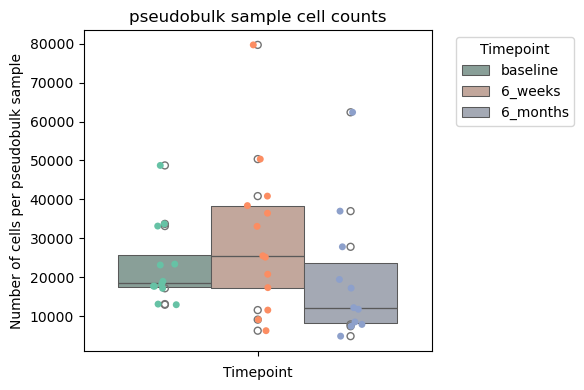

In [8]:
plt.figure(figsize=(6, 4))
sns.boxenplot(data=meta, y="n_cells", hue="timepoint_label", palette=palette, legend=True, saturation=0.25)
sns.stripplot(data=meta, y="n_cells", hue="timepoint_label", palette=palette, dodge=True, jitter=True, ax=plt.gca(), legend=False)
plt.xlabel("Timepoint")
plt.ylabel("Number of cells per pseudobulk sample")
plt.title("pseudobulk sample cell counts")
plt.legend(title="Timepoint", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
filename = output_dir / "COPD_pb_sample_cell_counts.pdf"
plt.savefig(filename, bbox_inches="tight")

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/1313878026.py:2: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxenplot(data=meta, y="n_cells", hue="treatment_arm", palette=palette, legend=True, saturation=0.25)
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/1313878026.py:3: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.stripplot(data=meta, y="n_cells", hue="treatment_arm", palette=palette, dodge=True, jitter=True, ax=plt.gca(), legend=False)


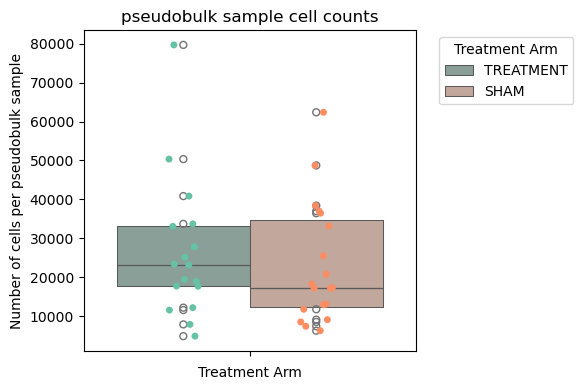

In [9]:
plt.figure(figsize=(6, 4))
sns.boxenplot(data=meta, y="n_cells", hue="treatment_arm", palette=palette, legend=True, saturation=0.25)
sns.stripplot(data=meta, y="n_cells", hue="treatment_arm", palette=palette, dodge=True, jitter=True, ax=plt.gca(), legend=False)
plt.xlabel("Treatment Arm")
plt.ylabel("Number of cells per pseudobulk sample")
plt.title("pseudobulk sample cell counts")
plt.legend(title="Treatment Arm", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
filename = output_dir / "COPD__treatmentarm_pb_sample_cell_counts.pdf"
plt.savefig(filename, bbox_inches="tight")

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/1760895471.py:2: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.lineplot(


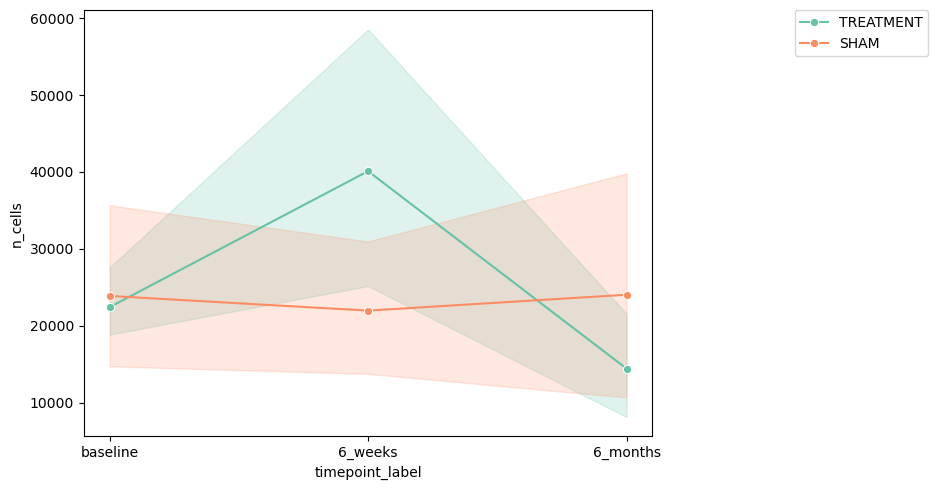

In [10]:
plt.figure(figsize=(10, 5))
ax = sns.lineplot(
    data=meta,
    x="timepoint_label",
    y="n_cells",
    hue="treatment_arm",
    palette=palette,
    marker="o"
)

ax.legend(bbox_to_anchor=(1.25, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()

# Subset data

In [27]:
#Subset on only conditi"on of interest (e.g. IPF vs control)

# # subset conditions of interest
subset_list = ["COPD"]
meta = meta[meta["condition"].isin(subset_list)]
meta

# subset timepoint - remove timepoints
# subset_timepoint = ["6_weeks", "6_months"] 
# meta = meta[~meta["timepoint_label"].isin(subset_timepoint)]
# meta

# create safe name for subset
subset_list_safe = safe_name("_vs_".join(subset_list))

# subset colors
col_palettes_subset = {k: col_palettes[k] for k in subset_list}

# Remove outlier samples
# outliers = ["COPD_R041_V3"]  # example outlier sample IDs
# meta = meta[~meta.index.isin(outliers)]
# Remove outlier samples
# outliers = ["COPD_R041", "COPD_R038"]  # example outlier sample IDs
# meta = meta[~meta["sample_ID"].isin(outliers)]

In [28]:
# subset the data
pb_sample = pb_sample[meta.index]
pb_sample.head()

,COPD_46005_V1,COPD_46005_V2,COPD_R003_V1,COPD_R003_V2,COPD_R003_V3,COPD_R009_V1,COPD_R009_V2,COPD_R009_V3,COPD_R010_V2,COPD_R011_V1,...,COPD_R036_V3,COPD_R038_V1,COPD_R038_V2,COPD_R038_V3,COPD_R039_V1,COPD_R039_V2,COPD_R039_V3,COPD_R041_V1,COPD_R041_V2,COPD_R041_V3
16S,68.0,144.0,19.0,318.0,10.0,30.0,745.0,473.0,297.0,98.0,...,141.0,157.0,555.0,61.0,357.0,222.0,138.0,68.0,171.0,409.0
A2ML1,0.0,1.0,1.0,1.0,0.0,0.0,4.0,4.0,0.0,3.0,...,1.0,4.0,9.0,1.0,7.0,3.0,2.0,0.0,0.0,3.0
AAMP,8.0,35.0,11.0,120.0,7.0,17.0,391.0,303.0,127.0,58.0,...,63.0,114.0,389.0,33.0,183.0,139.0,77.0,28.0,103.0,161.0
AAR2,0.0,6.0,1.0,25.0,3.0,2.0,92.0,108.0,27.0,12.0,...,25.0,35.0,99.0,10.0,58.0,53.0,22.0,7.0,37.0,57.0
AARSD1,1.0,9.0,1.0,20.0,4.0,3.0,66.0,63.0,31.0,19.0,...,17.0,16.0,91.0,3.0,42.0,22.0,12.0,6.0,10.0,34.0


/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_66750/1903322748.py:7: UserWarning: The palette list has more values (13) than needed (1), which may not be intended.
  sns.boxenplot(data=meta, y="n_cells", hue="condition", palette=high_num_colors, legend=True, saturation=0.25)
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_66750/1903322748.py:8: UserWarning: The palette list has more values (13) than needed (1), which may not be intended.
  sns.stripplot(data=meta, y="n_cells", hue="condition", palette=high_num_colors, dodge=True, jitter=True, ax=plt.gca(), legend=True)


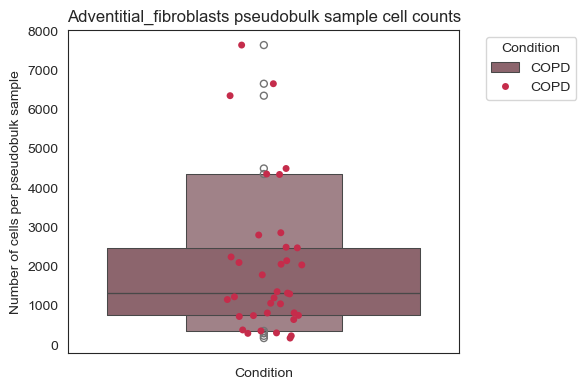

In [29]:
high_num_colors = sns.color_palette(
    "Spectral",
    n_colors=meta["sample_ID"].nunique()
)

plt.figure(figsize=(6, 4))
sns.boxenplot(data=meta, y="n_cells", hue="condition", palette=high_num_colors, legend=True, saturation=0.25)
sns.stripplot(data=meta, y="n_cells", hue="condition", palette=high_num_colors, dodge=True, jitter=True, ax=plt.gca(), legend=True)
plt.xlabel("Condition")
plt.ylabel("Number of cells per pseudobulk sample")
plt.title(f"{cell_type} pseudobulk sample cell counts")
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Calculate PC

In [11]:
X = pb_sample.T  # transpose to have samples as rows and genes as columns

# Filer for lowly expressed genes to reduce noise in PCA
min_count = 10  # minimum count threshold across all samples
gene_sums = X.sum(axis=0)  # sum of counts for each gene across all samples
genes_to_keep = gene_sums[gene_sums > min_count].index
X = X[genes_to_keep]  # filter the matrix to keep only the selected genes
filtered_gene_count = X

# Center and scale the data
X = np.log1p(X)  # log-transform the data
X_scaled = sklearn.preprocessing.StandardScaler().fit_transform(X)  # scale the data

# Calculate PCA
pca = sklearn.decomposition.PCA(n_components=4)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    pca_result, columns=["PC1", "PC2", "PC3", "PC4"], index=X.index
)

In [12]:
# Add back metadata to PCA dataframe for plottings
pca_df = pca_df.join(meta)

In [13]:
pca_df.shape

(58, 45)

# Plot PC and pairplot

Plotting PCA colored by 'batch'...


/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_15202/495137415.py:19: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.scatterplot(


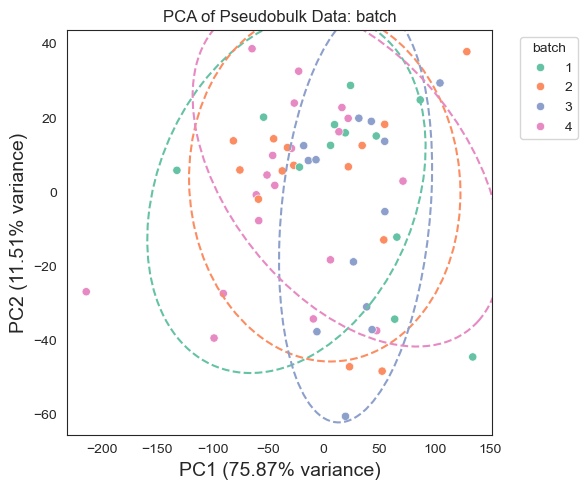

In [16]:
palette = sns.color_palette("Set2")
col_list = ["batch"]

for col in col_list:
    if col not in meta.columns:
        print(
            f"Column '{col}' not found in metadata. Skipping PCA plot for this column."
        )
        continue

    print(f"Plotting PCA colored by '{col}'...")

    sns.set_style("white")
    fig, ax = plt.subplots(figsize=(6, 5))

    groups = pca_df[col].unique()
    color_map = {g: palette[i % len(palette)] for i, g in enumerate(groups)}

    sns.scatterplot(
        data=pca_df, x="PC1", y="PC2", hue=col, 
        #size="n_cells", 
        palette=palette, ax=ax
    )

    # Draw ellipse per group
    for group, color in color_map.items():
        subset = pca_df[pca_df[col] == group]
        if len(subset) >= 2:
            confidence_ellipse(
                subset["PC1"].values,
                subset["PC2"].values,
                ax=ax,
                n_std=2.0,
                edgecolor=color,
                linewidth=1.5,
                linestyle="--",
            )

    ax.set_title(f"PCA of Pseudobulk Data: {col}")
    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)", fontsize=14
    )
    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)", fontsize=14
    )
    ax.legend(title=col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    filename = output_dir / f"all_{col}.pdf"
    plt.savefig(filename, bbox_inches="tight")
    

In [34]:
# Plot pairplot of first 4 PCs colored by column
for col in col_list:
    if col not in meta.columns:
        print(
            f"Column '{col}' not found in metadata. Skipping PCA plot for this column."
        )
        continue

    print(f"Plotting PCA colored by '{col}'...")
    sns.set_style("white")
    sns.pairplot(
        pca_df,
        vars=["PC1", "PC2", "PC3", "PC4"],
        hue=col,
        palette=palette,
        plot_kws={"s": 50},
    )
    plt.suptitle(f"PCA Pairplot of Pseudobulk Data: {col}")
    plt.tight_layout()
    plt.tight_layout()
    plt.savefig(dir / f"pseudobulk_data_celltype/{cell_type}/{cell_type}_{col}_{subset_list_safe}_pairplot.pdf", bbox_inches="tight")
    plt.close()



Plotting PCA colored by 'condition'...


/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWa

Plotting PCA colored by 'timepoint_label'...


/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWa

Plotting PCA colored by 'batch'...


/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWa

Column 'condition' not found in metadata. Skipping PCA plot for this column.


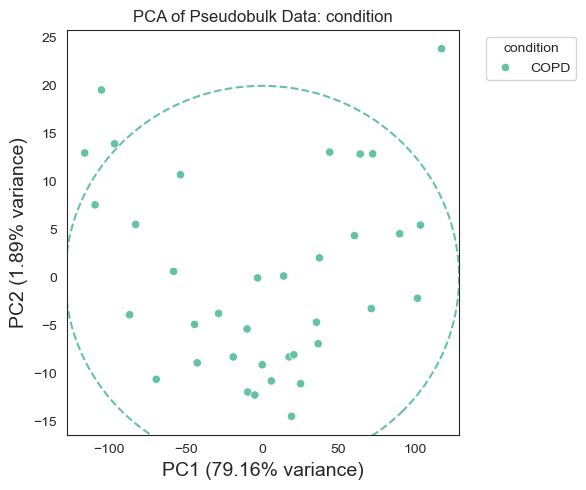

In [35]:
col_color = "condition"  # or "condition" or "sample_ID"

if col_color not in meta.columns:
    print(f"Column '{col_color}' not found in metadata. Skipping PCA plot for this column.")
if col_color == "condition":
    col_palettes_subset = {k: col_palettes[k] for k in subset_list}
if col_color == "timepoint_label":
    col_palettes = {"baseline": "#fc8d62", "6_weeks": "#66c2a5", "6_months": "#8da0cb"}
    col_palettes_subset = col_palettes
if col_color == "sample_ID":
    categories = pca_df[col_color].unique()
    palette = sns.color_palette("Spectral", n_colors=len(categories))
    col_palettes_subset = dict(zip(categories, palette))
else:
    print(f"Column '{col_color}' not found in metadata. Skipping PCA plot for this column.")

sns.set_style("white")
fig, ax = plt.subplots(figsize=(6, 5))

groups = pca_df[col_color].unique()

# build consistent palette
palette_map = {g: col_palettes_subset[g] for g in groups if g in col_palettes_subset}

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=col_color,
    #size="n_cells",
    palette=col_palettes_subset,
    ax=ax
)

# ellipses use SAME mapping
for group, color in palette_map.items():
    subset = pca_df[pca_df[col_color] == group]
    if len(subset) >= 2:
        confidence_ellipse(
            subset["PC1"].values,
            subset["PC2"].values,
            ax=ax,
            n_std=2.0,
            edgecolor=color,
            linewidth=1.5,
            linestyle="--",
        )

ax.set_title("PCA of Pseudobulk Data: condition")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)", fontsize=14)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)", fontsize=14)

ax.legend(title="condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig(dir / f"pseudobulk_data_celltype/{cell_type}/{cell_type}_condition_{subset_list_safe}_{col_color}_CORRECTCOLORS.pdf", bbox_inches="tight")
plt.tight_layout()

Column 'timepoint_label' not found in metadata. Skipping PCA plot for this column.


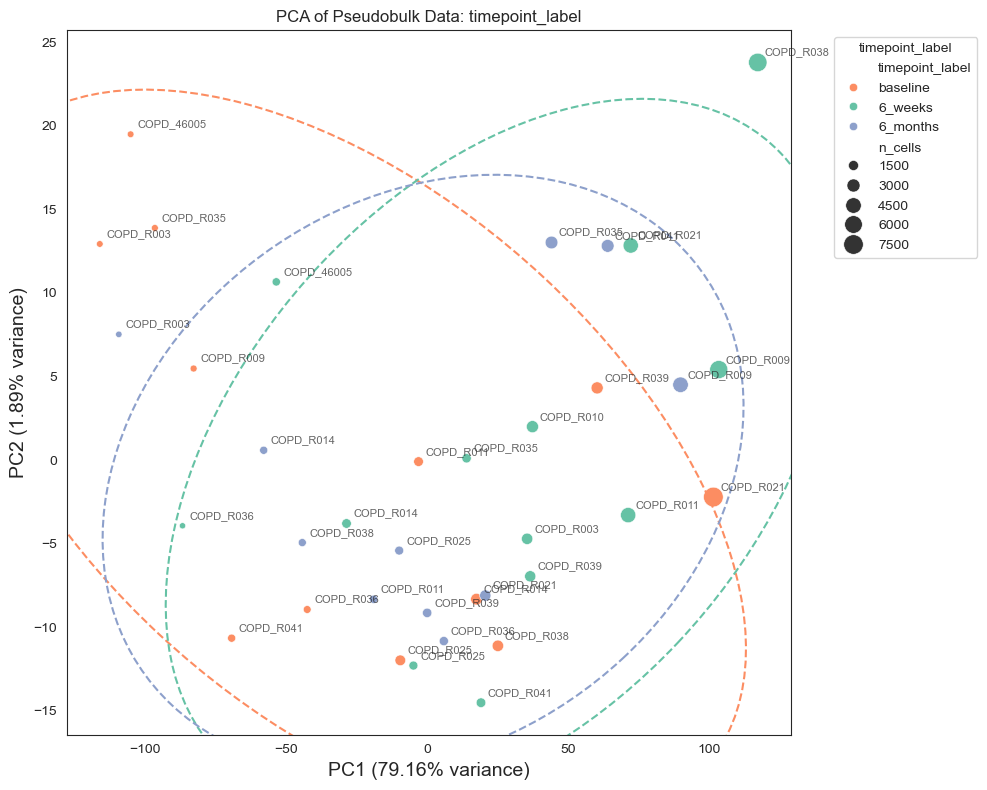

In [36]:
exploratory_col = "timepoint_label"  # or "condition" or "sample_ID"

if exploratory_col not in meta.columns:
    print(f"Column '{exploratory_col}' not found in metadata. Skipping PCA plot for this column.")
if exploratory_col == "condition":
    explore_col_palettes_subset = {k: col_palettes[k] for k in subset_list}
if exploratory_col == "timepoint_label":
    col_palettes = {"baseline": "#fc8d62", "6_weeks": "#66c2a5", "6_months": "#8da0cb"}
    explore_col_palettes_subset = col_palettes
if exploratory_col == "sample_ID":
    categories = pca_df[exploratory_col].unique()
    palette = sns.color_palette("husl", len(categories))
    #palette = sns.color_palette("Spectral", n_colors=len(categories))
    explore_col_palettes_subset = dict(zip(categories, palette))
else:
    print(f"Column '{exploratory_col}' not found in metadata. Skipping PCA plot for this column.")

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 8))

groups = pca_df[exploratory_col].unique()

# build consistent palette
palette_map = {g: explore_col_palettes_subset[g] for g in groups if g in explore_col_palettes_subset}

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=exploratory_col,
    size="n_cells",
    sizes=(20, 200),
    palette=explore_col_palettes_subset,
    ax=ax
)

for _, row in pca_df.iterrows():
    ax.annotate(
        str(row["sample_ID"]),
        (row["PC1"], row["PC2"]),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left",
        fontsize=8,
        alpha=0.7
    )

# ellipses use SAME mapping
for group, color in palette_map.items():
    subset = pca_df[pca_df[exploratory_col] == group]
    if len(subset) >= 2:
        confidence_ellipse(
            subset["PC1"].values,
            subset["PC2"].values,
            ax=ax,
            n_std=2.0,
            edgecolor=color,
            linewidth=1.5,
            linestyle="--",
        )

ax.set_title(f"PCA of Pseudobulk Data: {exploratory_col}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)", fontsize=14)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)", fontsize=14)

ax.legend(title=exploratory_col, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig(dir / f"pseudobulk_data_celltype/{cell_type}/{cell_type}_{exploratory_col}_{subset_list_safe}_{col_color}_CORRECTCOLORS_EXPLORE.pdf", bbox_inches="tight")
plt.tight_layout()

# Exploring genes driving PC
PCA loadings tell you which genes are creating the variation captured by a principal component
Loading describe genes - tells us what creates the separation, used for biological interpretation

Suppose PC1 separates:
- IPF samples on the right
- controls on the left
Then:
-  genes with positive loadings are enriched in IPF-like samples
-  genes with negative loadings are enriched in control-like samples

Gene	PC1 loading
COL1A1	+0.42
ACTA2	+0.39
CXCL8	-0.01
KRT19	-0.31

COL1A1 and ACTA2 strongly drive the positive PC1 direction
KRT19 drives the opposite direction
CXCL8 contributes minimally

In [37]:
# Extract loadings (n_components × n_genes)
loadings = pd.DataFrame(
    pca.components_,                    # shape: (n_components, n_genes)
    columns=X.columns,     # gene names (rows of your pb matrix)
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)
loadings

,16S,A2ML1,AAMP,AAR2,AARSD1,ABAT,ABCA1,ABCA3,ABCA4,ABCA7,...,ZPR1,ZSCAN1,ZSCAN12,ZSCAN16,ZSCAN20,ZSCAN26,ZSWIM6,ZUP1,ZYG11B,ZYX
PC1,0.014651,0.011306,0.015464,0.015107,0.014934,0.014228,0.015179,0.013764,0.012653,0.013322,...,0.015075,0.012966,0.014884,0.013785,0.014202,0.014792,0.014621,0.015144,0.014713,0.015295
PC2,-0.004433,0.022339,-0.005460,-0.019864,0.006569,0.003723,-0.008371,-0.010470,0.036366,0.015522,...,-0.006708,0.009772,-0.003075,0.001791,-0.004018,-0.005007,-0.009179,-0.006251,-0.012367,-0.009310
PC3,0.011017,-0.013956,0.007242,0.003881,-0.005443,-0.017123,0.007411,0.000486,-0.012087,-0.005519,...,-0.003017,-0.012391,-0.007340,-0.007476,-0.014714,-0.005611,-0.002486,0.001783,0.001279,0.003284
PC4,0.031211,-0.020903,0.001527,-0.004004,0.007094,-0.003701,0.011993,0.009675,0.002927,0.000327,...,0.007504,0.006299,-0.013492,-0.018685,-0.003210,0.001185,-0.005711,0.002097,-0.001525,0.018952


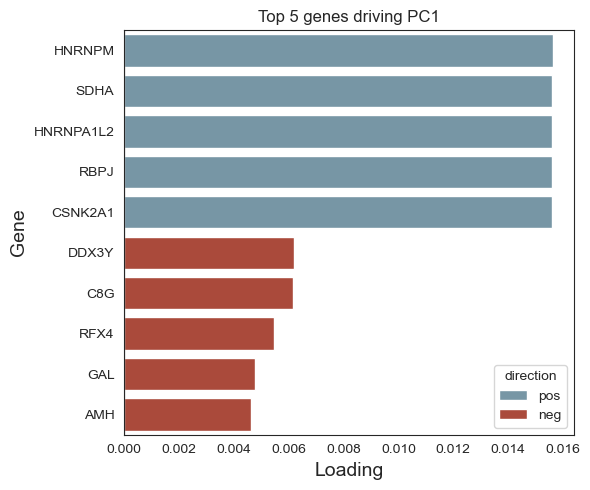

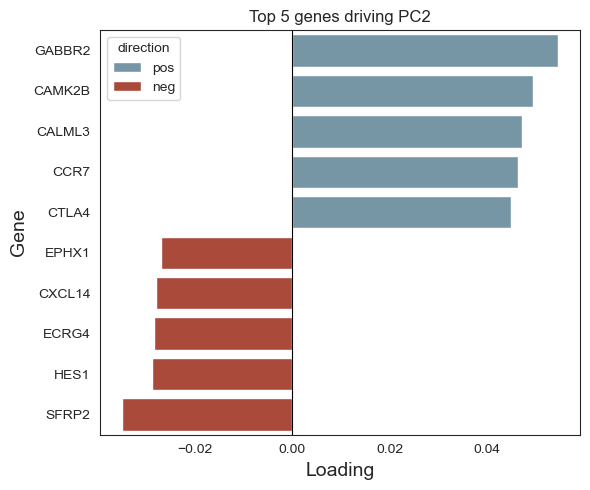

In [38]:
PC_dict = {}

# Number of top genes to show per PCs
N = 5

# Get top N positive and negative loadings for each PC
for pc in ["PC1", "PC2"]:
    s = loadings.loc[pc]

    top_pos = s.sort_values(ascending=False).head(N)
    top_neg = s.sort_values(ascending=True).head(N)

    top = pd.concat([top_pos, top_neg])

    df = pd.DataFrame({
        "loading": top,
        "direction": ["pos" if idx in top_pos.index else "neg" for idx in top.index]
    })

    df = df.sort_values("loading", ascending=False)

    PC_dict[pc] = df

# Plot loadings for top genes driving each PC
for pc in PC_dict.keys():
    df = PC_dict[pc]

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.barplot(x=df["loading"], y=df.index, ax=ax, hue=df["direction"], palette=["#6F99AD", "#BC3C29"])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top {N} genes driving {pc}")
    ax.set_xlabel("Loading", fontsize=14)
    ax.set_ylabel("Gene", fontsize=14)
    plt.tight_layout()
    plt.savefig(dir / f"pseudobulk_data_celltype/{cell_type}/pca_loadings_{pc}_{subset_list_safe}.pdf", bbox_inches="tight")
    plt.show()


In [39]:
PC_dict["PC1"]

,loading,direction
HNRNPM,0.015625,pos
SDHA,0.015613,pos
HNRNPA1L2,0.015610,pos
RBPJ,0.015609,pos
CSNK2A1,0.015608,pos
DDX3Y,0.006175,neg
C8G,0.006145,neg
RFX4,0.005469,neg
GAL,0.004778,neg
AMH,0.004612,neg


/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_66750/3448842984.py:7: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=col_color, palette=palette, ax=ax, s=80)


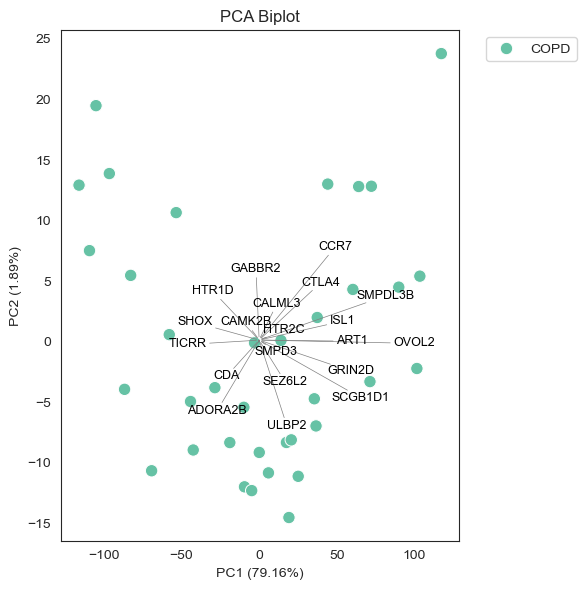

In [40]:
N_arrows = 20
scale = 3

fig, ax = plt.subplots(figsize=(6, 6))

# Sample scores
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=col_color, palette=palette, ax=ax, s=80)

# Gene arrows
loading_magnitude = np.sqrt(loadings.loc["PC1"]**2 + loadings.loc["PC2"]**2)
top_genes = loading_magnitude.nlargest(N_arrows).index

texts = []
for gene in top_genes:
    x = loadings.loc["PC1", gene] * scale
    y = loadings.loc["PC2", gene] * scale
    ax.arrow(
        0, 0, x, y,
        color="grey", alpha=0.7,
        head_width=0.03,
        length_includes_head=True,
        zorder=2
    )
    texts.append(ax.text(x * 1.1, y * 1.1, gene, fontsize=9, color="black"))

# Repel labels away from each other and from arrow tips
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="grey", lw=0.5),
    expand=(1.5, 1.5),       # how much to expand bounding boxes when checking overlap
    force_text=(0.5, 0.5),   # repulsion force between text objects
)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_title("PCA Biplot")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

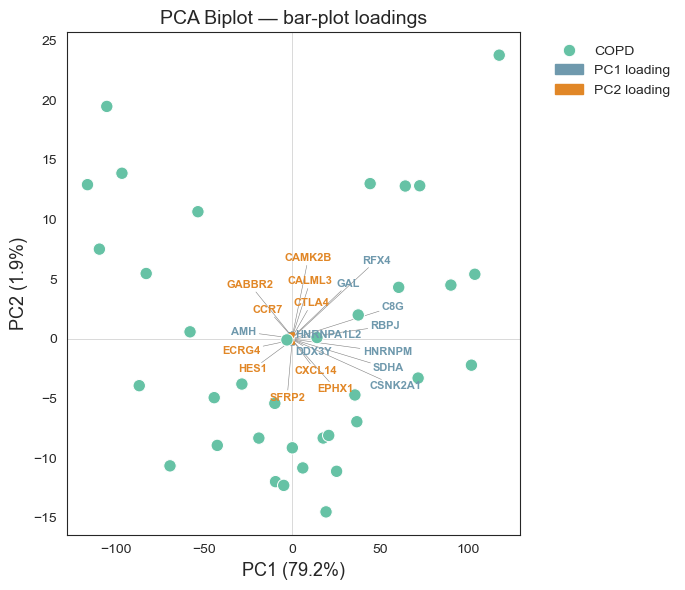

In [41]:
PC_dict = {}
for pc in ["PC1", "PC2"]:
    s = loadings.loc[pc]
    top_pos = s.sort_values(ascending=False).head(N)
    top_neg = s.sort_values(ascending=True).head(N)
    top = pd.concat([top_pos, top_neg])
    df = pd.DataFrame({
        "loading": top,
        "direction": ["pos" if idx in top_pos.index else "neg" for idx in top.index]
    })
    df = df.sort_values("loading", ascending=False)
    PC_dict[pc] = df

# Union of genes shown in either bar plot
biplot_genes = list(
    dict.fromkeys(                          # preserve rough order, deduplicate
        list(PC_dict["PC1"].index) +
        list(PC_dict["PC2"].index)
    )
)

# Arrow colour: dominant PC
# PC1-dominant genes → blue; PC2-dominant genes → orange
pc1_genes = set(PC_dict["PC1"].index)
pc2_genes = set(PC_dict["PC2"].index)

def arrow_color(gene):
    in1 = gene in pc1_genes
    in2 = gene in pc2_genes
    if in1 and in2:
        # shared gene: pick whichever PC has the larger absolute loading
        return "#6F99AD" if abs(loadings.loc["PC1", gene]) >= abs(loadings.loc["PC2", gene]) else "#E18727"
    elif in1:
        return "#6F99AD"   # PC1 blue
    else:
        return "#E18727"   # PC2 orange

# 3. Biplots
fig, ax = plt.subplots(figsize=(7, 6))

# Sample scores
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue=col_color, palette=col_palettes_subset,
    ax=ax, s=80, zorder=3
)

# Arrows + labels
texts = []
for gene in biplot_genes:
    x = loadings.loc["PC1", gene] * scale
    y = loadings.loc["PC2", gene] * scale
    color = arrow_color(gene)

    ax.annotate(
        "", xy=(x, y), xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=1.2,
            mutation_scale=8,
        ),
        zorder=2
    )
    texts.append(
        ax.text(x * 1.08, y * 1.08, gene,
                fontsize=8, color=color, fontweight="bold")
    )

# Repel labels
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="grey", lw=0.4),
    expand=(1.5, 1.5),
    force_text=(0.5, 0.5),
)

# Legend: conditions + PC arrow colours
handles, labels = ax.get_legend_handles_labels()
handles += [
    mpatches.Patch(color="#6F99AD", label="PC1 loading"),
    mpatches.Patch(color="#E18727", label="PC2 loading"),
]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

ax.axhline(0, color="lightgrey", linewidth=0.6, zorder=0)
ax.axvline(0, color="lightgrey", linewidth=0.6, zorder=0)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=13)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=13)
ax.set_title("PCA Biplot — bar-plot loadings", fontsize=14)

plt.tight_layout()
plt.savefig(
    dir / f"pseudobulk_data_celltype/{cell_type}/pca_biplot_{subset_list_safe}.pdf",
    bbox_inches="tight"
)
plt.show()

/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/sarapatti/miniforge3/envs/recode_st/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWa

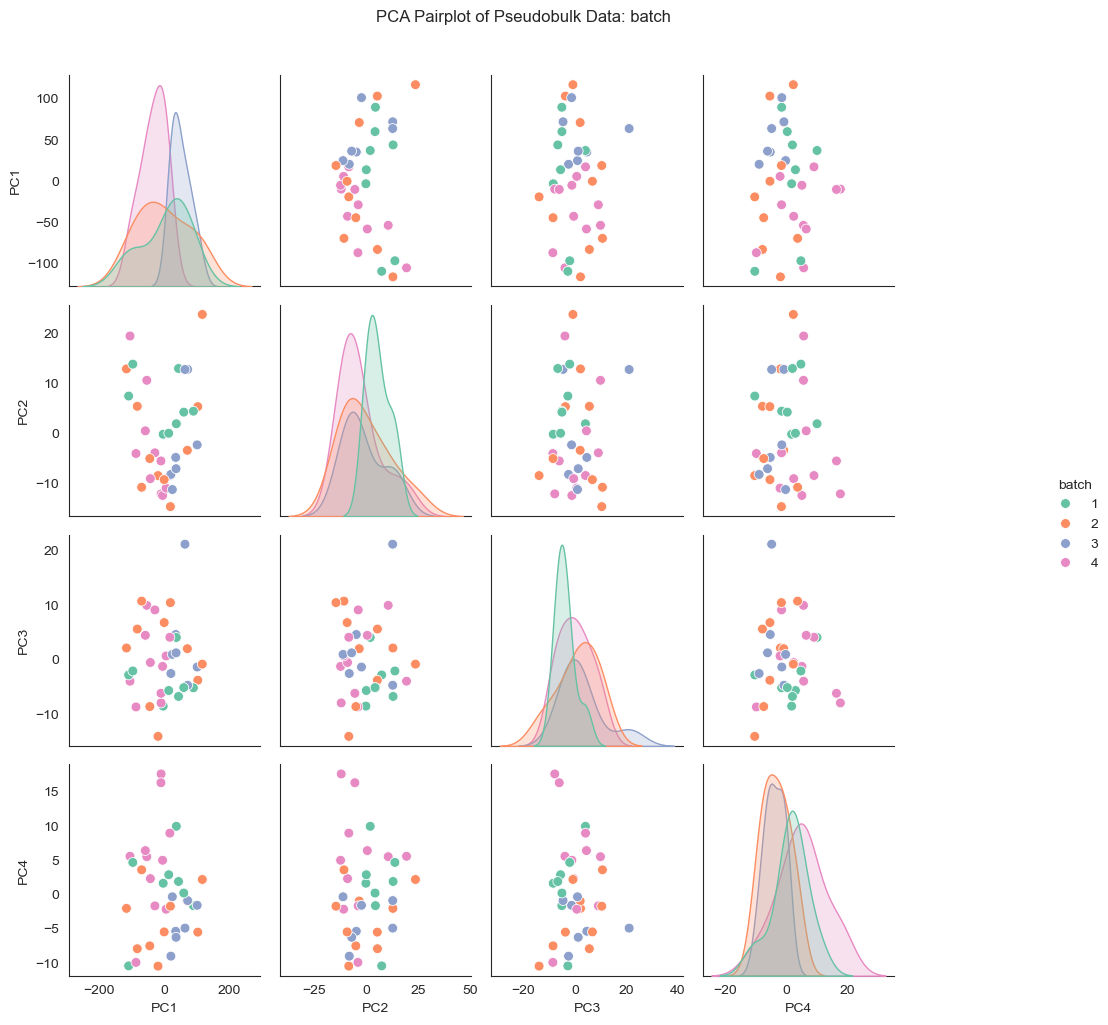

In [43]:
# Plot pairplot of PC1-PC4

plt.show()